In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from FNO import *
import pybamm
import flax

In [3]:
anode_file = "trained_models/anode_GRF_2025-03-07_11-21-21.msgpack"
cathode_file = "trained_models/cathode_GRF_2025-03-07_12-23-05.msgpack"

train_data = np.load("data/spm/train/GRF.npz")
test_data = np.load("data/spm/test/GRF.npz")

In [4]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn_anode = jnp.array(train_data["target_concentration_anode"])
test_cn_anode = jnp.array(test_data["target_concentration_anode"])

train_c0_anode = jnp.array(train_data["initial_concentration_anode"])
test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

train_cn_cathode = jnp.array(train_data["target_concentration_cathode"])
test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

train_c0_cathode = jnp.array(train_data["initial_concentration_cathode"])
test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [5]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [6]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
output_channels = 1

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar

# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
anode = model.apply(params, input_tensor)
cathode = model.apply(params, input_tensor)
print("Output shape:", anode.shape)  # should be (1,24,85,1)
print("Output shape:", cathode.shape)

Output shape: (1, 24, 85, 1)
Output shape: (1, 24, 85, 1)


In [7]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = jnp.zeros((num_samples, H, W, 4))
    Y = jnp.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)

    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = jnp.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = jnp.tile(c0_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = jnp.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = jnp.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)

    # Stack channels: (num_samples,24,85,4)
    X = jnp.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = jnp.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [8]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 3600
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [9]:
params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [10]:
train_idx = np.random.randint(2, 22000)
test_idx = np.random.randint(2, 2200)

In [11]:
X_train_anode, Y_train_anode = preprocess_data(train_I[train_idx:train_idx+2], train_c0_anode[train_idx:train_idx+2], train_cn_anode[train_idx:train_idx+2])
X_test_anode, Y_test_anode = preprocess_data(test_I, test_c0_anode, test_cn_anode)

X_train_cathode, Y_train_cathode = preprocess_data(train_I[train_idx:train_idx+2], train_c0_cathode[train_idx:train_idx+2], train_cn_cathode[train_idx:train_idx+2])
X_test_cathode, Y_test_cathode = preprocess_data(test_I, test_c0_cathode, test_cn_cathode)

In [12]:
c_train_true_anode = train_cn_anode[train_idx]
c_train_pred_anode = model.apply(params_anode,X_train_anode[0][None,...])

c_test_true_anode = test_cn_anode[test_idx]
c_test_pred_anode = model.apply(params_anode,X_test_anode[test_idx][None,...])

c_train_pred_reshaped_anode = c_train_pred_anode[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped_anode = c_train_true_anode  # already (20,75)

c_test_pred_reshaped_anode = c_test_pred_anode[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped_anode = c_test_true_anode  # already (20,75)


c_train_true_cathode = train_cn_cathode[train_idx]
c_train_pred_cathode = model.apply(params_cathode,X_train_cathode[0][None,...])

c_test_true_cathode = test_cn_cathode[test_idx]
c_test_pred_cathode = model.apply(params_cathode,X_test_cathode[test_idx][None,...])

c_train_pred_reshaped_cathode = c_train_pred_cathode[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped_cathode = c_train_true_cathode  # already (20,75)

c_test_pred_reshaped_cathode = c_test_pred_cathode[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped_cathode = c_test_true_cathode   # already (20,75)

In [13]:
c_pred_an_surf = c_test_pred_reshaped_anode[-1,:]
c_pred_ca_surf = c_test_pred_reshaped_cathode[-1,:]

c_true_an_surf = c_test_true_reshaped_anode[-1,:]
c_true_ca_surf = c_test_true_reshaped_cathode[-1,:]

In [14]:
func_I = train_I[test_idx]

In [15]:
c_train_pred_scaled_anode = c_train_pred_reshaped_anode * cs_max_a
c_test_pred_scaled_anode = c_test_pred_reshaped_anode * cs_max_a

c_test_true_scaled_anode = c_test_true_reshaped_anode * cs_max_a
c_train_true_scaled_anode = c_train_true_reshaped_anode * cs_max_a


c_train_pred_scaled_cathode = c_train_pred_reshaped_cathode * cs_max_c
c_test_pred_scaled_cathode = c_test_pred_reshaped_cathode * cs_max_c

c_test_true_scaled_cathode = c_test_true_reshaped_cathode * cs_max_c
c_train_true_scaled_cathode = c_train_true_reshaped_cathode * cs_max_c

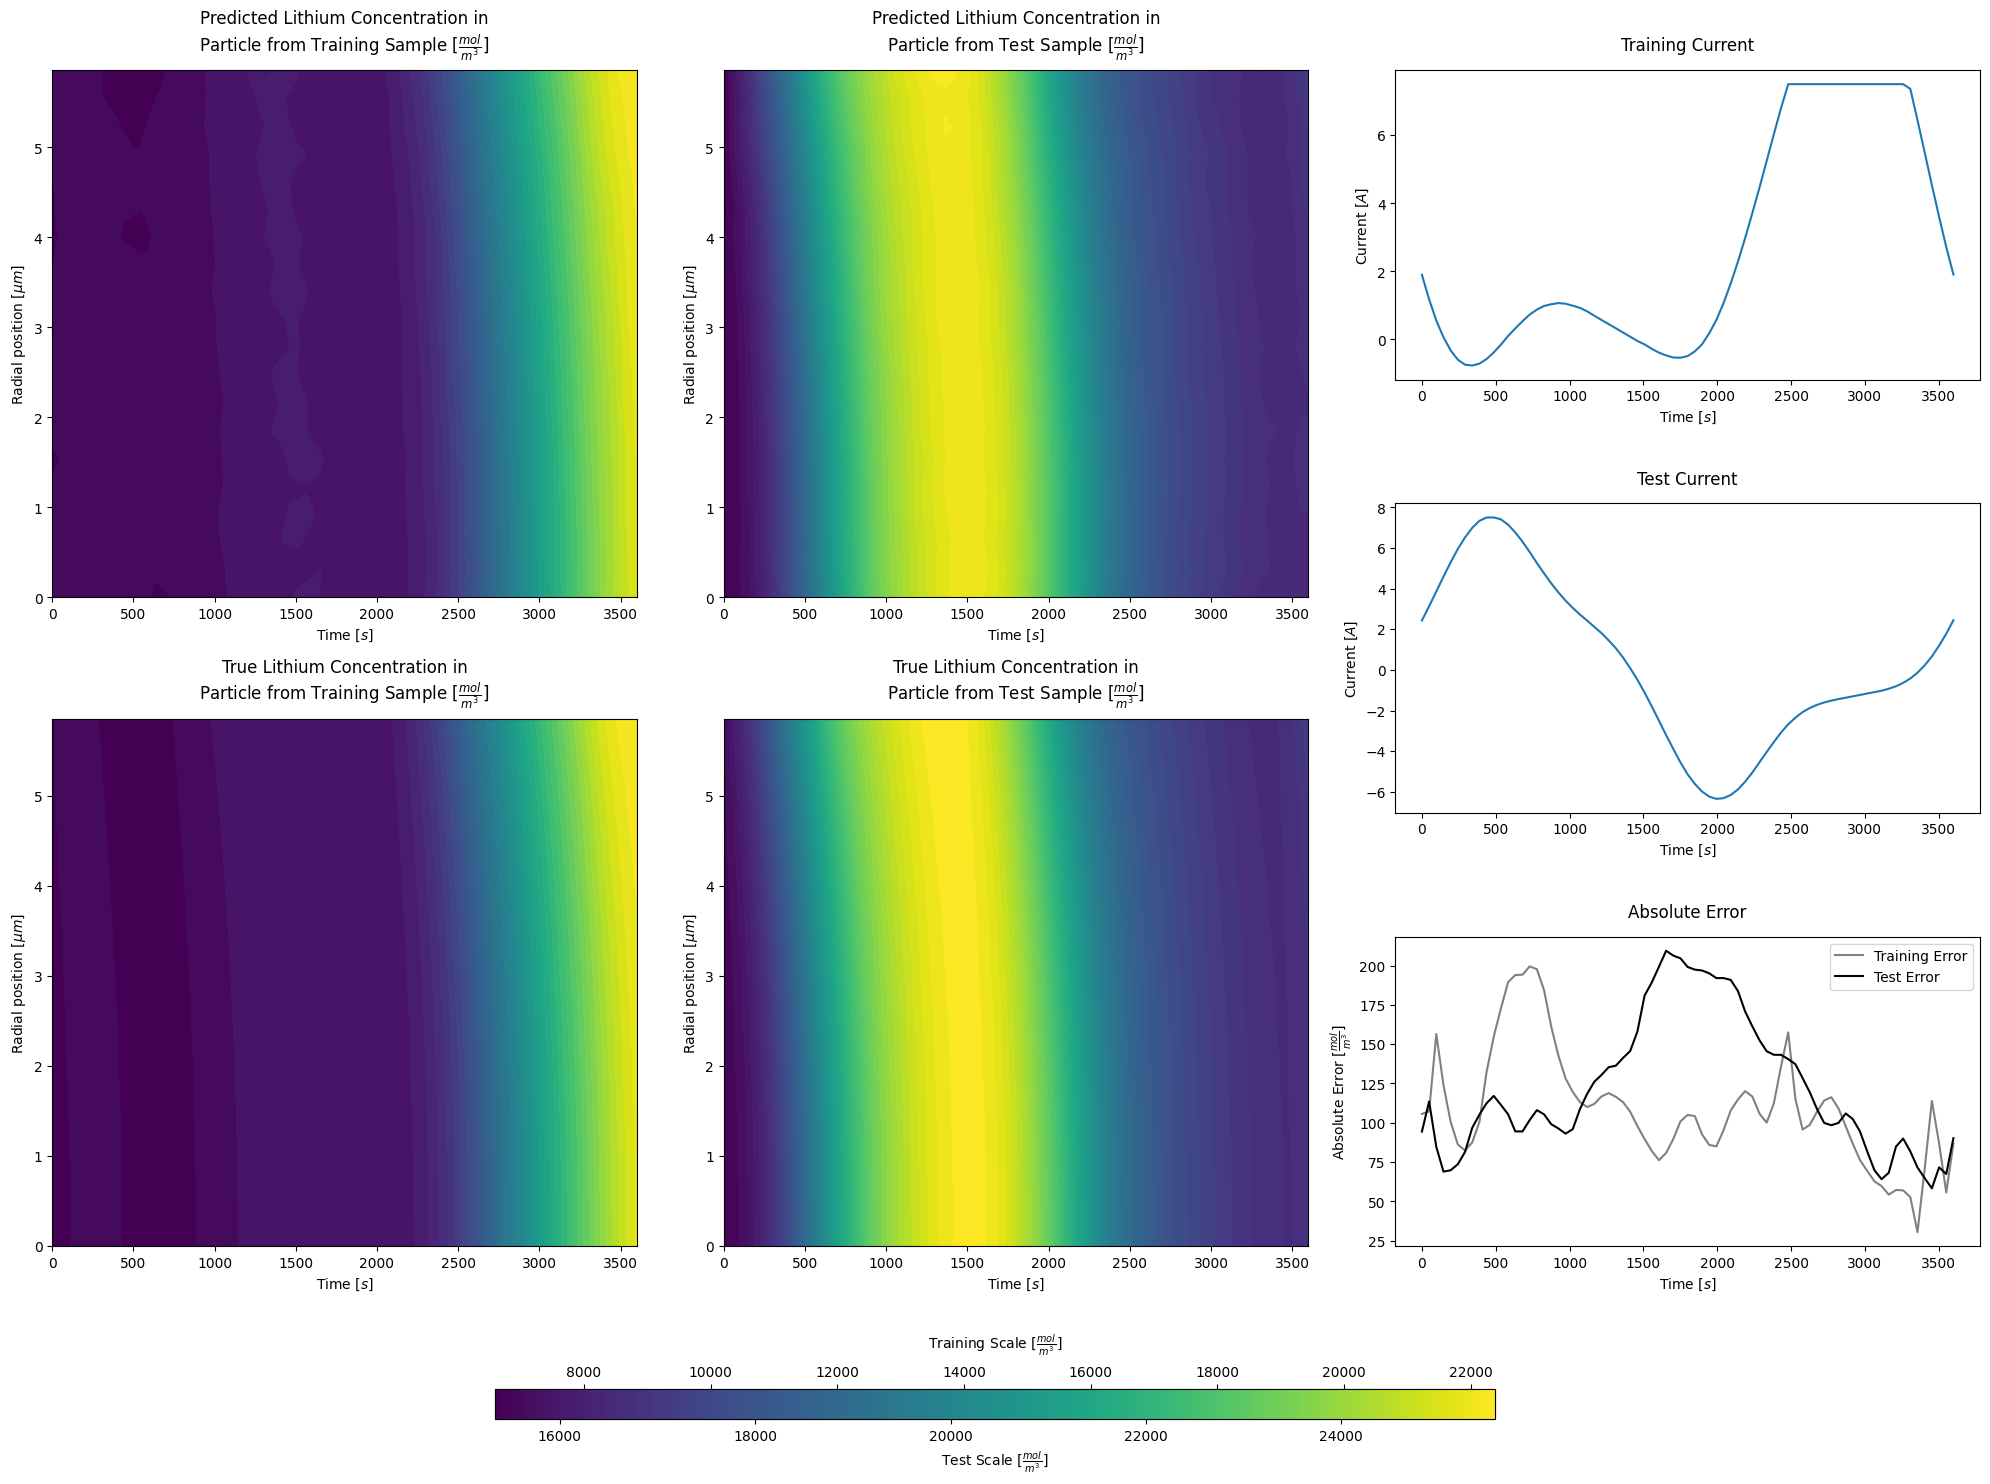

In [16]:
##ANODE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
train_error_line_anode = jnp.mean(jnp.abs(c_train_pred_scaled_anode - c_train_true_scaled_anode), axis=0)  # shape (75,)
test_error_line_anode = jnp.mean(jnp.abs(c_test_pred_scaled_anode - c_test_true_scaled_anode), axis=0)      # shape (75,)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled_anode.ravel(),
    c_train_true_scaled_anode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_anode.ravel(),
    c_test_true_scaled_anode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled_anode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line_anode, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line_anode, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

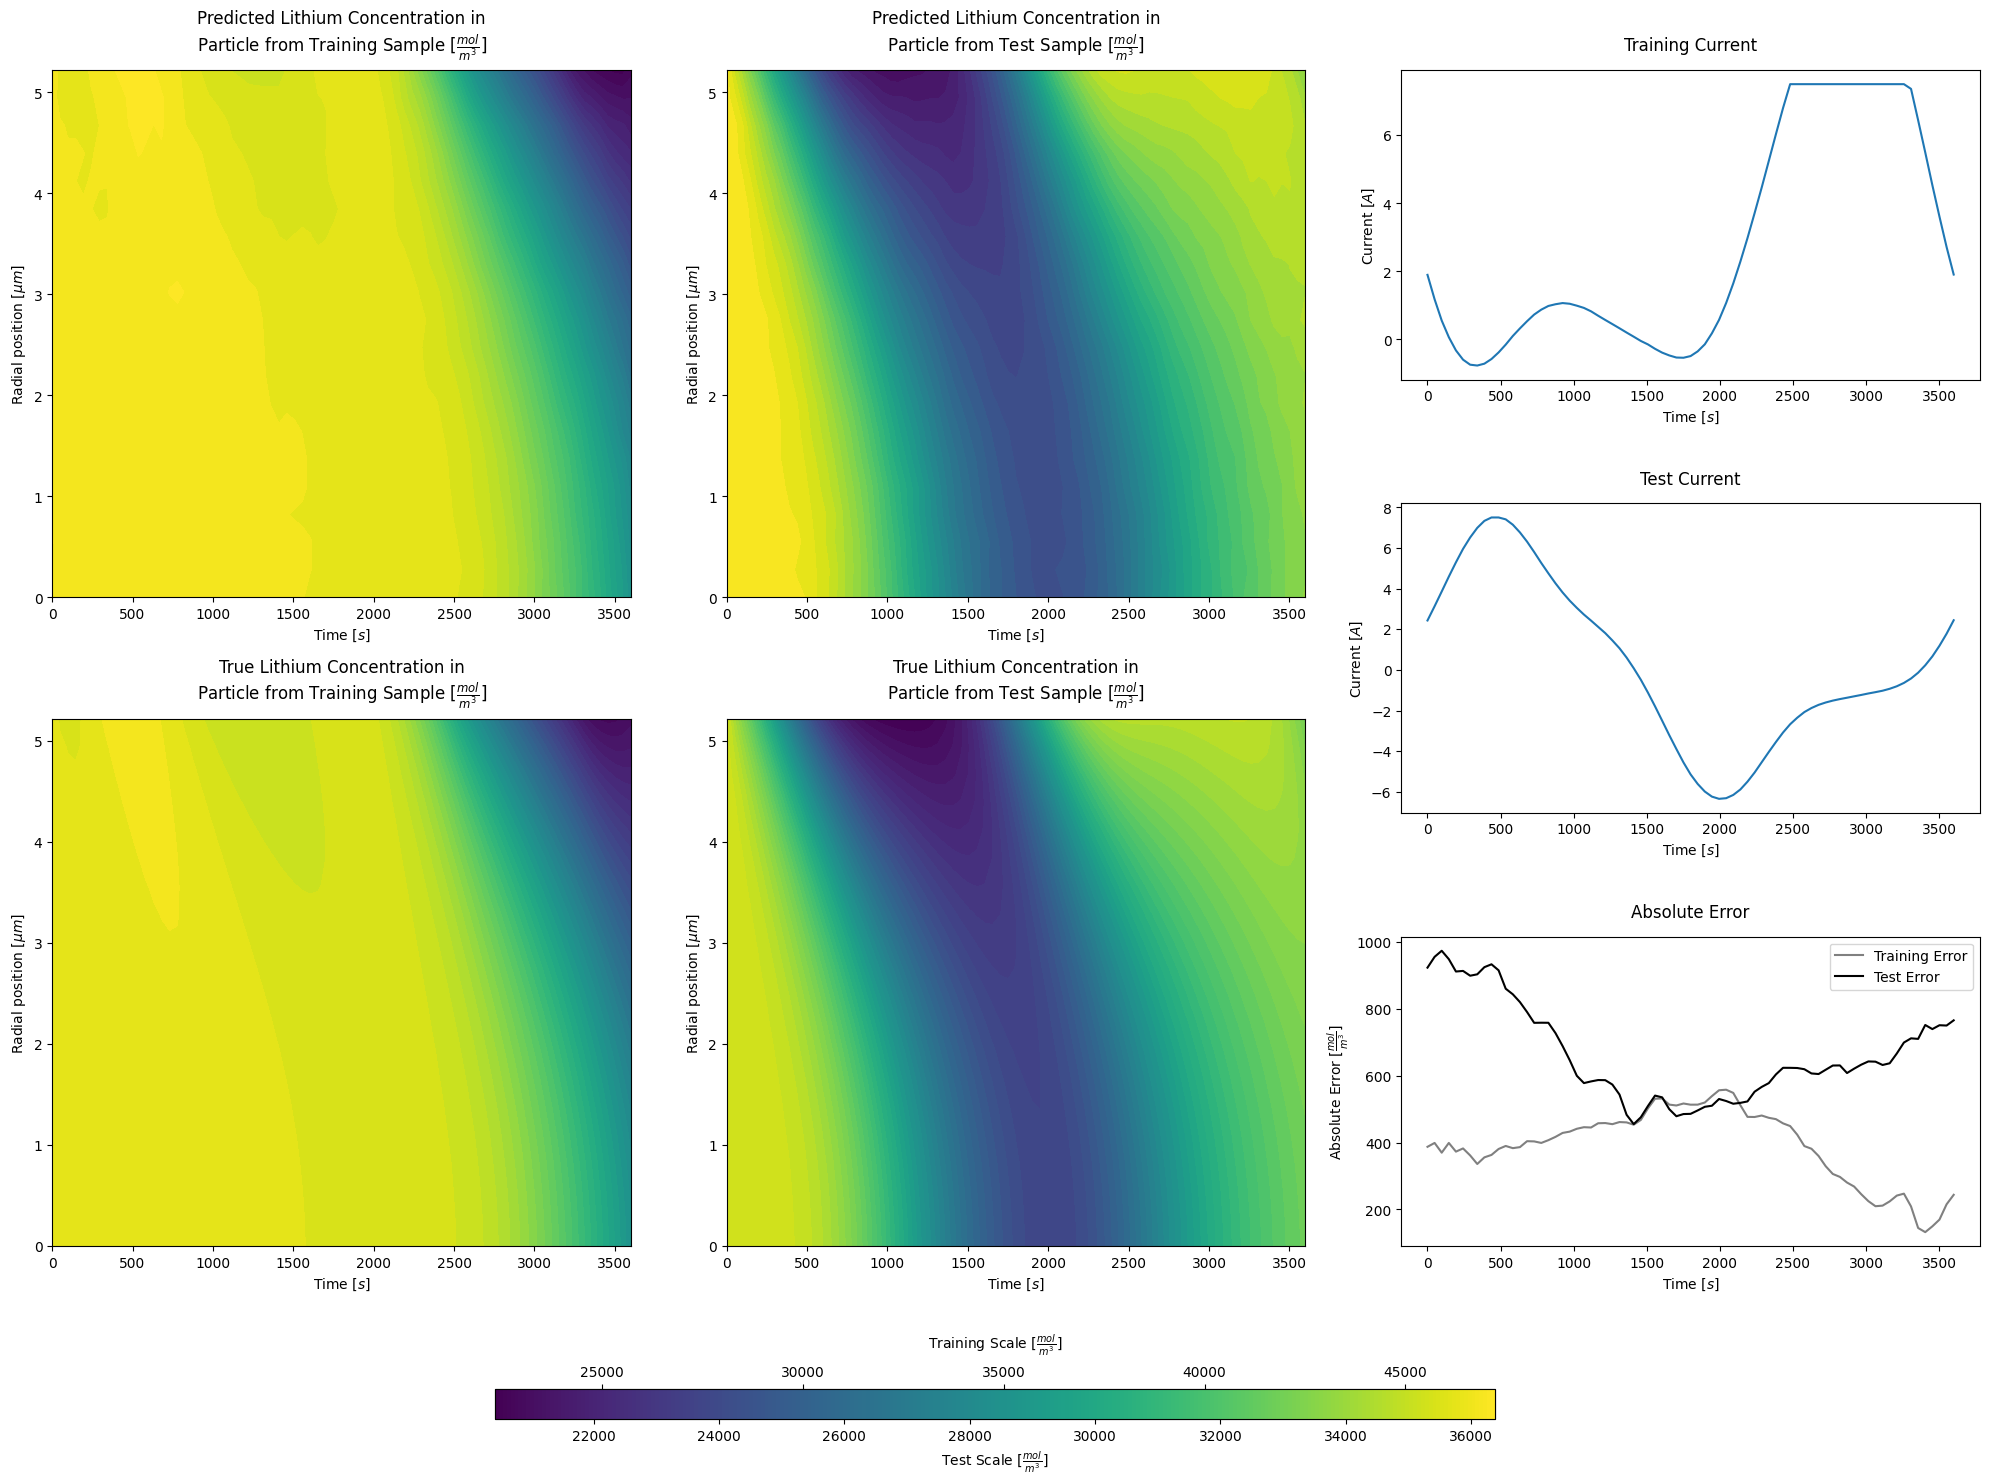

In [17]:
##CATHODE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
train_error_line_cathode = jnp.mean(jnp.abs(c_train_pred_scaled_cathode - c_train_true_scaled_cathode), axis=0)  # shape (75,)
test_error_line_cathode = jnp.mean(jnp.abs(c_test_pred_scaled_cathode - c_test_true_scaled_cathode), axis=0)      # shape (75,)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled_cathode.ravel(),
    c_train_true_scaled_cathode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_cathode.ravel(),
    c_test_true_scaled_cathode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Rca*1e6, c_train_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Rca*1e6, c_train_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Rca*1e6, c_test_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Rca*1e6, c_test_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line_cathode, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line_cathode, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [18]:
# Compute V_pred and V_true using post_proc function
#from functions import post_proc
V_pred, V_true = functions.post_proc(params_bat, test_I[test_idx], c_pred_an_surf/cs_max_a, c_true_an_surf/cs_max_a, c_pred_ca_surf/cs_max_c, c_true_ca_surf/cs_max_c, Ran, Rca, epsan, epsca, Lan, Lca, A)

In [19]:
func_I

Array([-7.5      , -7.5      , -7.5      , -7.5      , -7.5      ,
       -7.5      , -7.5      , -7.5      , -7.5      , -7.5      ,
       -7.5      , -7.5      , -7.5      , -7.5      , -7.5      ,
       -7.5      , -7.5      , -7.5      , -7.5      , -7.5      ,
       -7.5      , -7.5      , -7.5      , -7.5      , -7.5      ,
       -7.1266623, -6.6732364, -6.317879 , -6.084914 , -5.925247 ,
       -5.8805404, -5.942532 , -6.057929 , -6.23228  , -6.4305644,
       -6.6131253, -6.794879 , -6.9287434, -7.0164123, -7.0407953,
       -7.008439 , -6.903924 , -6.775596 , -6.589098 , -6.3950944,
       -6.17478  , -5.960444 , -5.7769976, -5.6157703, -5.4909916,
       -5.416066 , -5.3905363, -5.4045143, -5.468097 , -5.554211 ,
       -5.6857386, -5.793086 , -5.8956866, -5.9854074, -6.0483446,
       -6.09157  , -6.122581 , -6.1417828, -6.1880507, -6.254889 ,
       -6.3755875, -6.5573125, -6.7954426, -7.099568 , -7.470643 ,
       -7.5      , -7.5      , -7.5      , -7.5      , -7.5   

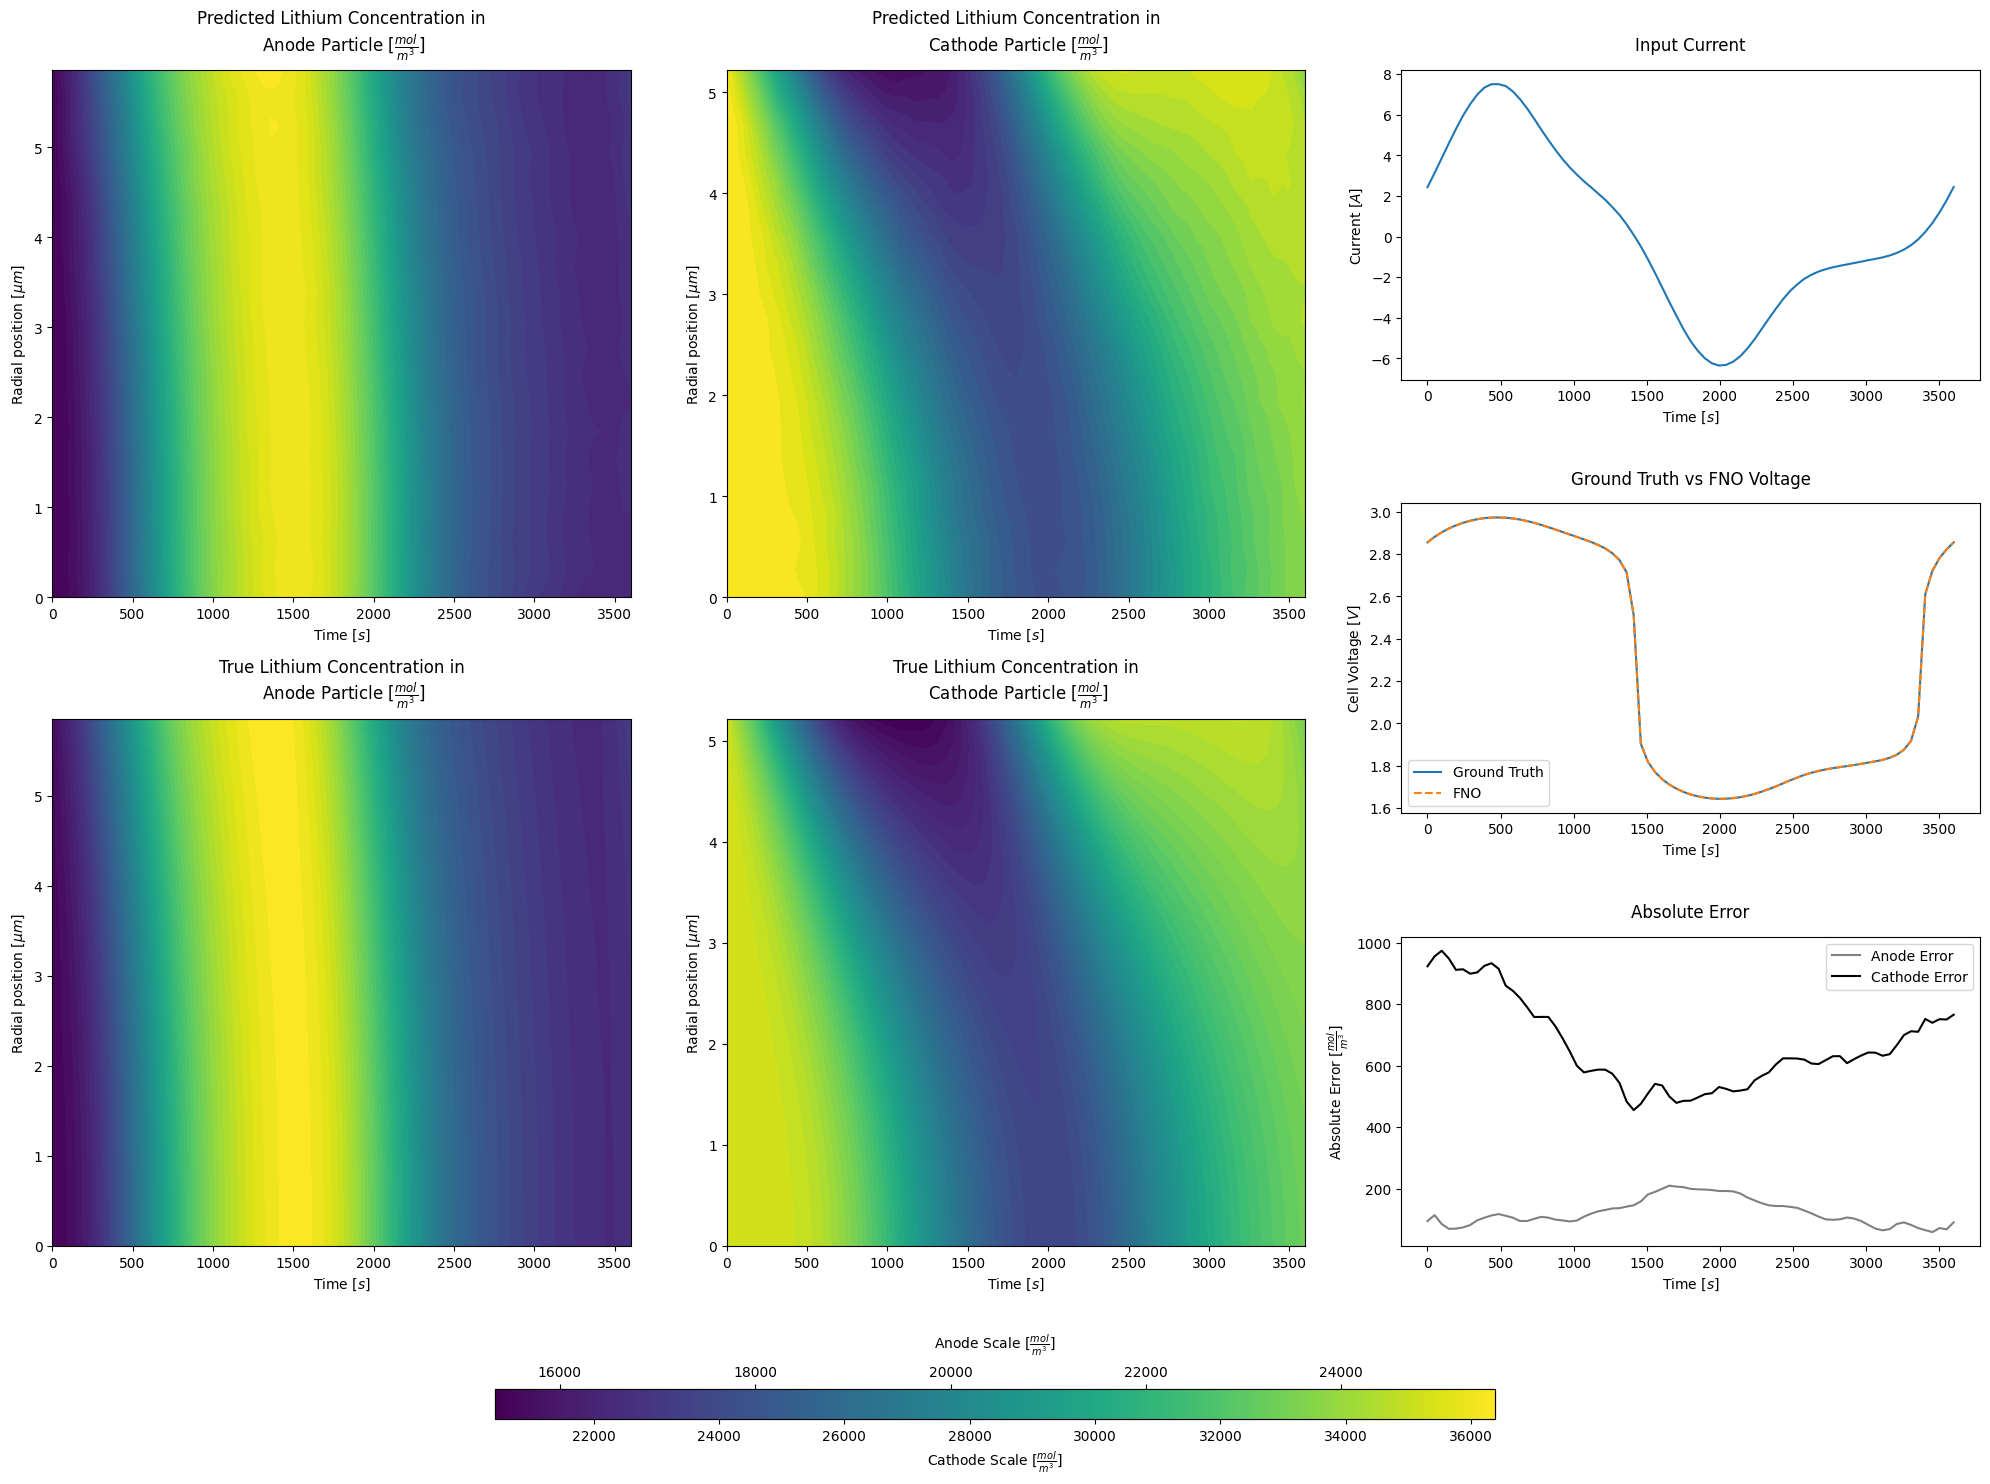

In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
anode_error_line = jnp.mean(jnp.abs(c_test_pred_scaled_anode - c_test_true_scaled_anode), axis=0)  # shape (75,)
cathode_error_line = jnp.mean(jnp.abs(c_test_pred_scaled_cathode - c_test_true_scaled_cathode), axis=0)      # shape (75,)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_test_pred_scaled_anode.ravel(),
    c_test_true_scaled_anode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_cathode.ravel(),
    c_test_true_scaled_cathode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\n Anode Particle [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\n Anode Particle [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Rca*1e6, c_test_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\n Cathode Particle [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Rca*1e6, c_test_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\n Cathode Particle [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, test_I[test_idx])
ax_curr.set_title('Input Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, V_true, label='Ground Truth', linestyle='-')
ax_volt.plot(t, V_pred, label='FNO', linestyle='--')
ax_volt.set_title('Ground Truth vs FNO Voltage', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Cell Voltage [$V$]')
ax_volt.legend()

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, anode_error_line, color='grey', label='Anode Error', linestyle='-')
ax_err.plot(t, cathode_error_line, color='black', label='Cathode Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Anode Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Cathode Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("plots/FNO/Voltage" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=600)
plt.show()

In [53]:
test_idx

1028

In [47]:
import pybamm

spm = pybamm.lithium_ion.SPM()
spm.events = []

soc = np.floor(test_idx/200)/10

params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* test_I[test_idx], pybamm.t)

sim = pybamm.Simulation(spm, parameter_values=params_bat)#, solver=fast_solver)
sol = sim.solve(initial_soc=soc, t_eval=t)

sol.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [48]:
c0_anode = sol["Negative particle concentration"].entries[:,0,0]
cn_target_anode = sol["Negative particle concentration"].entries[:,0,:]

c0_cathode = sol["Positive particle concentration"].entries[:,0,0]
cn_target_cathode = sol["Positive particle concentration"].entries[:,0,:]

In [49]:
cn_target_anode

array([[0.46847971, 0.46859056, 0.47071309, ..., 0.50098615, 0.50200131,
        0.50410731],
       [0.46847971, 0.46860162, 0.47077921, ..., 0.50099555, 0.50202856,
        0.50415558],
       [0.46847971, 0.46862504, 0.47091316, ..., 0.50101485, 0.50208369,
        0.50425281],
       ...,
       [0.46847971, 0.47722777, 0.48688894, ..., 0.50459661, 0.5087383 ,
        0.51443583],
       [0.46847971, 0.47920491, 0.48949362, ..., 0.50533133, 0.50989142,
        0.51606113],
       [0.46847971, 0.48148071, 0.49238143, ..., 0.50618258, 0.51119544,
        0.51787484]])

In [54]:
np.allclose(test_cn_anode[test_idx].flatten(),cn_target_anode.flatten())

True

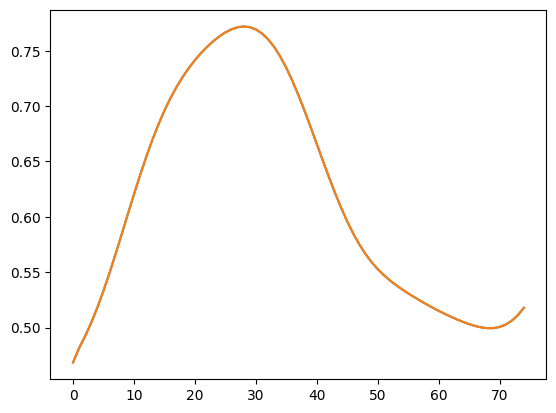

In [51]:
plt.plot(test_cn_anode[test_idx][-1,:])
plt.plot(cn_target_anode[-1,:])

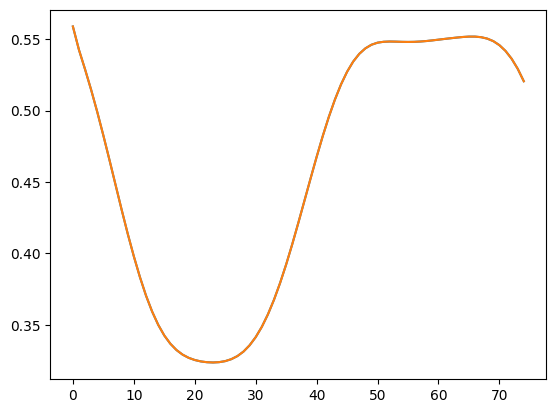

In [52]:
plt.plot(test_cn_cathode[test_idx][-1,:])
plt.plot(cn_target_cathode[-1,:])